In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
 
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
 
print("Imports done.")

Imports done.


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/Sample_Submission.csv
/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/train.csv
/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/test.csv


In [3]:
train_df = pd.read_csv('/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/gauravmalik26/food-delivery-dataset/test.csv')
 
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (45593, 20)
Test shape: (11399, 19)


In [4]:
print("Columns:")
print(train_df.columns.tolist())
print()
print("Dtypes:")
print(train_df.dtypes)
print()
train_df.head(5)

Columns:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']

Dtypes:
ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   obj

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [5]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)
train_df.info()

print("\n" + "="*60)
print("NUMERICAL SUMMARY")
print("="*60)
print(train_df.describe())

print("\n" + "="*60)
print("CATEGORICAL SUMMARY")
print("="*60)
print(train_df.describe(include='object'))

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)
print(train_df.duplicated().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 

TARGET VARIABLE
count        45593
unique          45
top       (min) 26
freq          2123
Name: Time_taken(min), dtype: object


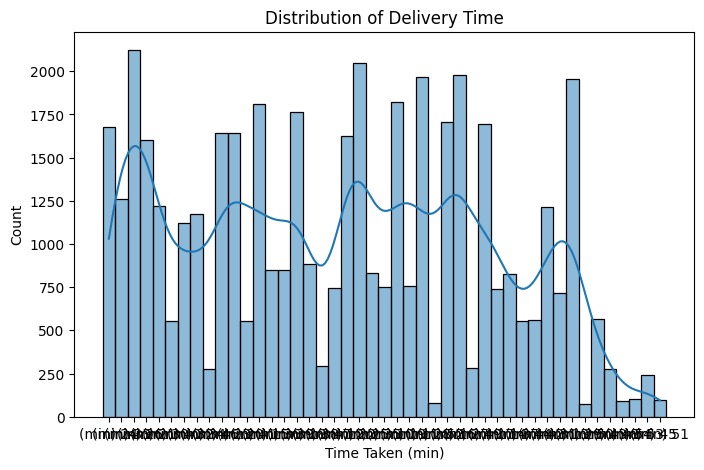


UNIQUE VALUES IN CATEGORICAL COLUMNS

ID
['0x4607 ' '0xb379 ' '0x5d6d ' ... '0x4f8d ' '0x5eee ' '0x5fb2 ']

Delivery_person_ID
['INDORES13DEL02 ' 'BANGRES18DEL02 ' 'BANGRES19DEL01 ' ...
 'KOCRES04DEL01 ' 'BHPRES06DEL03 ' 'GOARES03DEL03 ']

Delivery_person_Age
['37' '34' '23' '38' '32' '22' '33' '35' '36' '21' '24' '29' '25' '31'
 '27' '26' '20' 'NaN ' '28' '39' '30' '15' '50']

Delivery_person_Ratings
['4.9' '4.5' '4.4' '4.7' '4.6' '4.8' '4.2' '4.3' '4' '4.1' '5' '3.5'
 'NaN ' '3.8' '3.9' '3.7' '2.6' '2.5' '3.6' '3.1' '2.7' '1' '3.2' '3.3'
 '6' '3.4' '2.8' '2.9' '3']

Order_Date
['19-03-2022' '25-03-2022' '05-04-2022' '26-03-2022' '11-03-2022'
 '04-03-2022' '14-03-2022' '20-03-2022' '12-02-2022' '13-02-2022'
 '14-02-2022' '02-04-2022' '01-03-2022' '16-03-2022' '15-02-2022'
 '10-03-2022' '27-03-2022' '12-03-2022' '01-04-2022' '05-03-2022'
 '11-02-2022' '08-03-2022' '03-04-2022' '30-03-2022' '28-03-2022'
 '18-03-2022' '06-04-2022' '04-04-2022' '24-03-2022' '09-03-2022'
 '02-03-2022' '13

In [6]:
print("="*60)
print("TARGET VARIABLE")
print("="*60)

print(train_df["Time_taken(min)"].describe())

plt.figure(figsize=(8,5))
sns.histplot(train_df["Time_taken(min)"], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Time Taken (min)")
plt.show()

print("\n" + "="*60)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*60)

cat_cols = train_df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}")
    print(train_df[col].unique())

In [7]:
print("="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

missing_train = train_df.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

missing_test = test_df.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

print("\nTrain Dataset")
print(pd.DataFrame({
    "Missing Values": missing_train,
    "Percentage": (missing_train / len(train_df) * 100).round(2)
}))

print("\nTest Dataset")
print(pd.DataFrame({
    "Missing Values": missing_test,
    "Percentage": (missing_test / len(test_df) * 100).round(2)
}))

MISSING VALUE ANALYSIS

Train Dataset
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

Test Dataset
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


In [8]:
print("="*60)
print("EXPOSING HIDDEN NULLS & CLEANING STRINGS")
print("="*60)

# Function to clean hidden NaNs and weird strings
def clean_fake_nulls(df):
    cat_cols = df.select_dtypes(include='object').columns
    
    for col in cat_cols:
        # 1. Remove trailing/leading spaces (Fixes 'High ' -> 'High')
        df[col] = df[col].astype(str).str.strip()
        
        # 2. Fix the Weatherconditions specific bug ("conditions Sunny" -> "Sunny")
        if col == 'Weatherconditions':
            df[col] = df[col].str.replace('conditions ', '', regex=False)
            
        # 3. Replace literal strings with actual numpy NaN
        # Notice we added 'NaN' (which was 'conditions NaN' before the above step)
        df[col] = df[col].replace(['NaN', 'nan', 'None', '', 'NA', 'null'], np.nan)
    
    return df

print("Cleaning Train Data...")
train_df = clean_fake_nulls(train_df)

print("Cleaning Test Data...")
test_df = clean_fake_nulls(test_df)

# ============================================================
# Target Variable Fix: "(min) 24" -> 24.0
# ============================================================
if 'Time_taken(min)' in train_df.columns:
    print("\nFixing Target Variable Format in Train...")
    train_df['Time_taken(min)'] = train_df['Time_taken(min)'].astype(str).str.extract(r'(\d+)').astype(float)

# Now let's check the TRUE missing values
print("\n" + "="*60)
print("ACTUAL MISSING VALUES (TRAIN)")
print("="*60)
true_missing_train = train_df.isnull().sum()
print(true_missing_train[true_missing_train > 0].sort_values(ascending=False))

print("\n" + "="*60)
print("ACTUAL MISSING VALUES (TEST)")
print("="*60)
true_missing_test = test_df.isnull().sum()
print(true_missing_test[true_missing_test > 0].sort_values(ascending=False))

EXPOSING HIDDEN NULLS & CLEANING STRINGS
Cleaning Train Data...
Cleaning Test Data...

Fixing Target Variable Format in Train...

ACTUAL MISSING VALUES (TRAIN)
Delivery_person_Ratings    1908
Delivery_person_Age        1854
Time_Orderd                1731
City                       1200
multiple_deliveries         993
Weatherconditions           616
Road_traffic_density        601
Festival                    228
dtype: int64

ACTUAL MISSING VALUES (TEST)
Delivery_person_Ratings    507
Delivery_person_Age        491
Time_Orderd                444
City                       324
multiple_deliveries        238
Weatherconditions          158
Road_traffic_density       154
Festival                    65
dtype: int64


In [9]:
print("="*60)
print("FILLING NULL VALUES (IMPUTATION)")
print("="*60)

def impute_missing_values(train, test):
    # 1. Categorical Columns -> Fill with Mode
    cat_cols = ['Weatherconditions', 'Road_traffic_density', 'City', 'Festival']
    for col in cat_cols:
        if col in train.columns:
            mode_val = train[col].mode()[0]
            train[col] = train[col].fillna(mode_val)
            test[col] = test[col].fillna(mode_val)

    # 2. Numerical Columns -> Convert to float and Fill with Median
    num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
    for col in num_cols:
        if col in train.columns:
            train[col] = train[col].astype(float)
            test[col] = test[col].astype(float)
            
            median_val = train[col].median()
            train[col] = train[col].fillna(median_val)
            test[col] = test[col].fillna(median_val)
            
    # ============================================================
    # 3. Mathematical Time Imputation (Prep-Time Offset)
    # ============================================================
    print("\nCalculating Median Prep Time for intelligent imputation...")
    
    # Temporary datetime conversion for math
    for df in [train, test]:
        df['temp_ord'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce')
        df['temp_pick'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce')
    
    # Sirf Train data se median nikalenge taaki Test data leak na ho
    prep_diff_mins = (train['temp_pick'] - train['temp_ord']).dt.total_seconds() / 60
    # Rat ke 12 baje cross hone waale negative times aur extreme outliers ko ignore karo
    valid_prep_times = prep_diff_mins[(prep_diff_mins > 0) & (prep_diff_mins < 120)]
    median_prep = valid_prep_times.median()
    print(f"Calculated Median Prep Time: {median_prep} minutes")

    for df in [train, test]:
        # Agar Picked time missing hai = Ordered Time + Median Prep
        df['temp_pick'] = df['temp_pick'].fillna(df['temp_ord'] + pd.Timedelta(minutes=median_prep))
        
        # Agar Ordered time missing hai = Picked Time - Median Prep
        df['temp_ord'] = df['temp_ord'].fillna(df['temp_pick'] - pd.Timedelta(minutes=median_prep))
        
        # Aakhri raasta: Agar fir bhi koi bach gaya (dono missing), toh ffill lagayenge
        df['temp_ord'] = df['temp_ord'].ffill().bfill()
        df['temp_pick'] = df['temp_pick'].ffill().bfill()
        
        # Wapas original HH:MM:SS string format mein convert kar do
        df['Time_Orderd'] = df['temp_ord'].dt.strftime('%H:%M:%S')
        df['Time_Order_picked'] = df['temp_pick'].dt.strftime('%H:%M:%S')
        
        # Kachra saaf karo
        df.drop(columns=['temp_ord', 'temp_pick'], inplace=True)
            
    return train, test

# Apply the function
train_df, test_df = impute_missing_values(train_df, test_df)

# Drop any remaining extremely weird rows only from TRAIN
train_df = train_df.dropna(subset=['Time_taken(min)']) 

print("Nulls left in Train data:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print("\nNulls left in Test data:")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])
print("\nImputation Complete! We are ready for Feature Engineering.")

FILLING NULL VALUES (IMPUTATION)

Calculating Median Prep Time for intelligent imputation...
Calculated Median Prep Time: 10.0 minutes
Nulls left in Train data:
Series([], dtype: int64)

Nulls left in Test data:
Series([], dtype: int64)

Imputation Complete! We are ready for Feature Engineering.


In [10]:
print("="*60)
print("ANOMALY DETECTION & FIXING (DATA INTEGRITY)")
print("="*60)

def fix_anomalies(df, dataset_name="Train"):
    print(f"\nScanning {dataset_name} Data...")

    # 1. Ratings Anomaly (Max rating is 5.0)
    invalid_ratings = df[df['Delivery_person_Ratings'] > 5.0]
    if len(invalid_ratings) > 0:
        print(f"🚨 Found {len(invalid_ratings)} rows with Rating > 5.0. Capping to 5.0...")
        df.loc[df['Delivery_person_Ratings'] > 5.0, 'Delivery_person_Ratings'] = 5.0

    # 2. Age Anomaly (Legal driving age in India is 18. Max practical is say 65)
    underage = df[df['Delivery_person_Age'] < 18]
    if len(underage) > 0:
        print(f"🚨 Found {len(underage)} rows with Age < 18. Setting to 18 (Legal minimum)...")
        df.loc[df['Delivery_person_Age'] < 18, 'Delivery_person_Age'] = 18
        
    overage = df[df['Delivery_person_Age'] > 65]
    if len(overage) > 0:
        print(f"🚨 Found {len(overage)} rows with Age > 65. Capping to 65...")
        df.loc[df['Delivery_person_Age'] > 65, 'Delivery_person_Age'] = 65

    # 3. Batched Orders Anomaly (More than 3 batched orders in quick commerce is impossible)
    weird_deliveries = df[df['multiple_deliveries'] > 3]
    if len(weird_deliveries) > 0:
        print(f"⚠️ Found {len(weird_deliveries)} rows with >3 batched deliveries. Capping at 3...")
        df.loc[df['multiple_deliveries'] > 3, 'multiple_deliveries'] = 3

    return df

# Apply the fixes
train_df = fix_anomalies(train_df, "Train")
test_df = fix_anomalies(test_df, "Test")

print("\n✅ Anomalies Fixed! Now the data is logically and mathematically bound.")

ANOMALY DETECTION & FIXING (DATA INTEGRITY)

Scanning Train Data...
🚨 Found 53 rows with Rating > 5.0. Capping to 5.0...
🚨 Found 38 rows with Age < 18. Setting to 18 (Legal minimum)...

Scanning Test Data...
🚨 Found 10 rows with Rating > 5.0. Capping to 5.0...
🚨 Found 9 rows with Age < 18. Setting to 18 (Legal minimum)...

✅ Anomalies Fixed! Now the data is logically and mathematically bound.


In [11]:
import numpy as np
import pandas as pd

print("="*60)
print("THE ULTIMATE FEATURE ENGINEERING")
print("="*60)

# ============================================================
# 1. Date Engineering (Has to be done BEFORE dropping Order_Date)
# ============================================================
print("📅 Extracting Day and Weekend features...")
for df in [train_df, test_df]:
    df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')
    df['Day_of_Week'] = df['Order_Date'].dt.dayofweek
    df['Is_Weekend'] = np.where(df['Day_of_Week'].isin([5, 6]), 1, 0)
    
    # Fill any nulls with median/mode (3 = Wednesday, 0 = Not Weekend)
    df['Day_of_Week'] = df['Day_of_Week'].fillna(3)
    df['Is_Weekend'] = df['Is_Weekend'].fillna(0)

# ============================================================
# 2. Haversine Distance
# ============================================================
def calculate_haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

print("🗺️ Calculating Last-Mile Delivery Distances...")
for df in [train_df, test_df]:
    df['distance_km'] = calculate_haversine(
        df['Restaurant_latitude'], df['Restaurant_longitude'],
        df['Delivery_location_latitude'], df['Delivery_location_longitude']
    )

# ============================================================
# 3. Cyclic Time Encoding
# ============================================================
print("⏱️ Applying Cyclic Encoding to Time variables...")
def encode_cyclic_time(df, col_name):
    time_parts = df[col_name].str.split(':', expand=True).astype(float)
    decimal_hours = time_parts[0] + (time_parts[1] / 60.0) + (time_parts[2] / 3600.0)
    df[f'{col_name}_sin'] = np.sin(2 * np.pi * decimal_hours / 24)
    df[f'{col_name}_cos'] = np.cos(2 * np.pi * decimal_hours / 24)
    return df

train_df = encode_cyclic_time(train_df, 'Time_Orderd')
test_df = encode_cyclic_time(test_df, 'Time_Orderd')

# ============================================================
# 4. STRICT NOMINAL & ORDINAL ENCODING 
# ============================================================
print("📈 Applying Ordinal Encoding...")
traffic_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Jam': 3}
weather_map = {'Sunny': 0, 'Cloudy': 1, 'Windy': 2, 'Fog': 3, 'Sandstorms': 4, 'Stormy': 5}
festival_map = {'No': 0, 'Yes': 1}

for df in [train_df, test_df]:
    df['Road_traffic_density'] = df['Road_traffic_density'].map(traffic_map).fillna(1)
    df['Weatherconditions'] = df['Weatherconditions'].map(weather_map).fillna(1)
    df['Festival'] = df['Festival'].map(festival_map).fillna(0)

print("🔠 Applying One-Hot Encoding...")
nominal_cols = ['Type_of_order', 'Type_of_vehicle', 'City']
train_df = pd.get_dummies(train_df, columns=nominal_cols, drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=nominal_cols, drop_first=True, dtype=int)

train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

# ============================================================
# 5. Drop Garbage Columns
# ============================================================
cols_to_drop = [
    'ID', 'Delivery_person_ID', 'Order_Date', 
    'Time_Orderd', 'Time_Order_picked', 
    'Restaurant_latitude', 'Restaurant_longitude', 
    'Delivery_location_latitude', 'Delivery_location_longitude'
]

train_df = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
test_df = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])

print("\n💾 SUCCESS: Final Feature Engineering Complete!")
print(f"Train data ready shape: {train_df.shape}")
print(f"Test data ready shape: {test_df.shape}")

THE ULTIMATE FEATURE ENGINEERING
📅 Extracting Day and Weekend features...
🗺️ Calculating Last-Mile Delivery Distances...
⏱️ Applying Cyclic Encoding to Time variables...
📈 Applying Ordinal Encoding...
🔠 Applying One-Hot Encoding...

💾 SUCCESS: Final Feature Engineering Complete!
Train data ready shape: (45593, 21)
Test data ready shape: (11399, 21)


In [12]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

print("="*60)
print("PHASE 3: XGBOOST MODEL TRAINING & VALIDATION")
print("="*60)

# ============================================================
# 1. Define Features (X) and Target (y)
# ============================================================
# Check exactly what columns are left before dropping
print("Preparing Data...")
X = train_df.drop(columns=['Time_taken(min)'])
y = train_df['Time_taken(min)']

# Save feature column names for SHAP and Streamlit later
feature_columns = X.columns.tolist()

# ============================================================
# 2. Train-Validation Split (80/20)
# ============================================================
# We split train_df to locally evaluate our model
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {X_train.shape[0]} rows, Validating on {X_val.shape[0]} rows...\n")

# ============================================================
# 3. Model Initialization & Training
# ============================================================
print("🔥 Firing up XGBoost Regressor (This will take a few seconds)...")
xgb_model = xgb.XGBRegressor(
    n_estimators=400,        # Number of trees to build
    learning_rate=0.05,      # Slow and steady learning for better generalization
    max_depth=7,             # Depth of each tree
    subsample=0.8,           # Use 80% of rows per tree to prevent overfitting
    colsample_bytree=0.8,    # Use 80% of columns per tree to prevent overfitting
    random_state=42,
    n_jobs=-1                # Use all available CPU cores
)

xgb_model.fit(X_train, y_train)

# ============================================================
# 4. Evaluation Metrics
# ============================================================
val_preds = xgb_model.predict(X_val)

mae = mean_absolute_error(y_val, val_preds)
r2 = r2_score(y_val, val_preds)

print("\n" + "="*50)
print("🎯 MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"R-squared Score (R2):      {r2:.4f}")
print("="*50)

# ============================================================
# 5. Save Artifacts
# ============================================================
# Save the model and feature columns locally in the Kaggle working directory
joblib.dump(xgb_model, 'xgboost_eta_model.pkl')
joblib.dump(feature_columns, 'logisurge_features.pkl')

print("\n💾 SUCCESS: Model and Feature list saved successfully.")
print("Check your Kaggle working directory (Output tab) for the .pkl files.")

PHASE 3: XGBOOST MODEL TRAINING & VALIDATION
Preparing Data...
Training on 36474 rows, Validating on 9119 rows...

🔥 Firing up XGBoost Regressor (This will take a few seconds)...

🎯 MODEL PERFORMANCE METRICS
Mean Absolute Error (MAE): 3.20 minutes
R-squared Score (R2):      0.8179

💾 SUCCESS: Model and Feature list saved successfully.
Check your Kaggle working directory (Output tab) for the .pkl files.


In [13]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import time
import joblib

print("="*60)
print("PHASE 4: HYPERPARAMETER TUNING & CROSS-VALIDATION")
print("="*60)

# ============================================================
# 1. Define The Parameter Grid (The Engine Specs)
# ============================================================
# Hum ek realistic aur compute-friendly grid de rahe hain
param_dist = {
    'n_estimators': [300, 400, 600, 800],        # Number of trees
    'max_depth': [5, 7, 9, 11],                  # Complexity of each tree
    'learning_rate': [0.01, 0.05, 0.1, 0.2],     # Speed of learning
    'subsample': [0.7, 0.8, 0.9],                # Row sampling (prevents overfitting)
    'colsample_bytree': [0.7, 0.8, 0.9]          # Column sampling
}

# ============================================================
# 2. Initialize the Base Model
# ============================================================
xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

# ============================================================
# 3. Setup RandomizedSearchCV with 3-Fold Cross Validation
# ============================================================
print("⏳ Starting Randomized Search with 3-Fold CV...")
print("⚠️ Warning: This will train 30 separate XGBoost models (10 iterations * 3 folds).")
print("Sit tight, this might take 2 to 5 minutes depending on Kaggle's server load...\n")

start_time = time.time()
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,                             # It will try 10 random combinations
    scoring='neg_mean_absolute_error',     # We want to minimize MAE
    cv=3,                                  # 3-Fold Cross Validation
    verbose=2,                             # Prints live progress updates
    random_state=42,
    n_jobs=-1
)

# ============================================================
# 4. Train the Grid (Only on X_train to prevent data leakage)
# ============================================================
random_search.fit(X_train, y_train)
end_time = time.time()

print("\n" + "="*50)
print("🏆 TUNING COMPLETE!")
print(f"Time Taken: {(end_time - start_time)/60:.2f} minutes")
print("="*50)

# ============================================================
# 5. Extract Best Parameters & Validate
# ============================================================
best_model = random_search.best_estimator_

print("\nBest Parameters Discovered by Math:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

# Validate this new 'Ultimate' model against our hold-out validation set (X_val)
tuned_preds = best_model.predict(X_val)
tuned_mae = mean_absolute_error(y_val, tuned_preds)

print(f"\n🚀 OLD BASELINE MAE: 3.20 minutes")
print(f"🚀 NEW TUNED MAE:     {tuned_mae:.2f} minutes")

# Overwrite the old saved model with this new beast
joblib.dump(best_model, 'xgboost_eta_model.pkl')
print("\n💾 Tuned Model has successfully overwritten 'xgboost_eta_model.pkl'")

PHASE 4: HYPERPARAMETER TUNING & CROSS-VALIDATION
⏳ Starting Randomized Search with 3-Fold CV...
⚠️ Warning: This will train 30 separate XGBoost models (10 iterations * 3 folds).
Sit tight, this might take 2 to 5 minutes depending on Kaggle's server load...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

🏆 TUNING COMPLETE!
Time Taken: 1.08 minutes

Best Parameters Discovered by Math:
 - subsample: 0.7
 - n_estimators: 600
 - max_depth: 11
 - learning_rate: 0.01
 - colsample_bytree: 0.8

🚀 OLD BASELINE MAE: 3.20 minutes
🚀 NEW TUNED MAE:     3.16 minutes

💾 Tuned Model has successfully overwritten 'xgboost_eta_model.pkl'


In [14]:
from sklearn.metrics import r2_score
import joblib

# 1. Naya tuned model load karo jo abhi save hua tha
tuned_model = joblib.load('xgboost_eta_model.pkl')

# 2. Validation set par naye predictions nikalo
tuned_preds = tuned_model.predict(X_val)

# 3. Naya R2 score calculate karo
new_r2 = r2_score(y_val, tuned_preds)

print("="*50)
print(f"🚀 OLD BASELINE R2: 0.8179")
print(f"🚀 NEW TUNED R2:    {new_r2:.4f}")
print("="*50)

🚀 OLD BASELINE R2: 0.8179
🚀 NEW TUNED R2:    0.8215


PHASE 5: SHAP INTERPRETABILITY (THE BLACK BOX REVEALED)


🔍 Calculating SHAP values (This might take a minute)...

📊 1. THE SUMMARY PLOT (Macro View)
Showing the overall impact of features across the dataset:


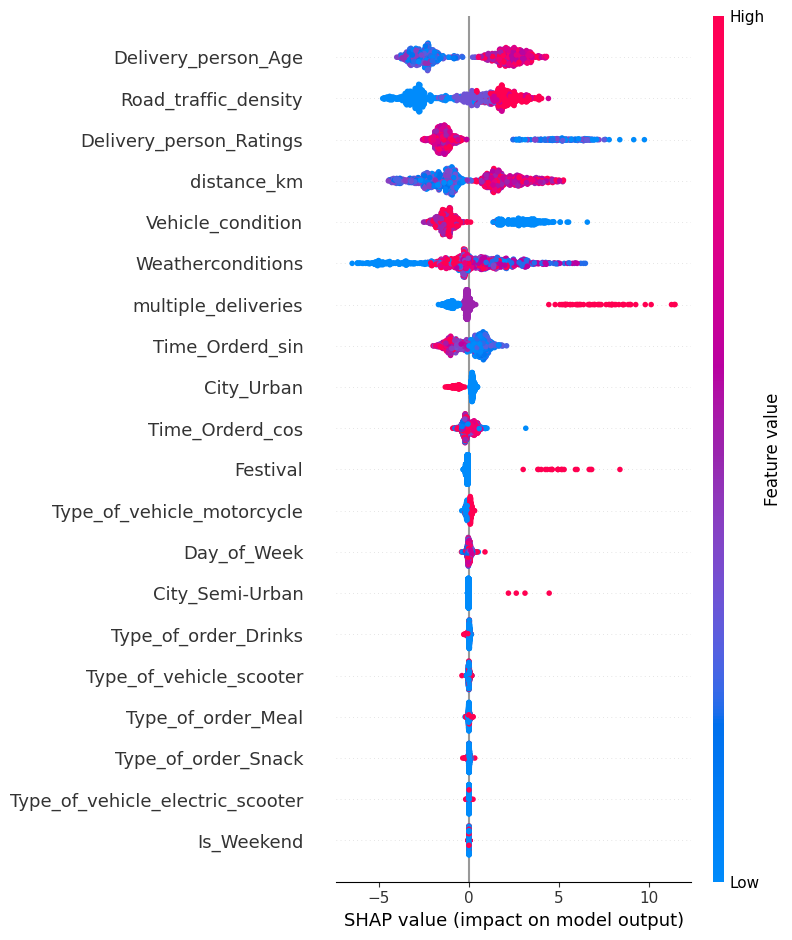


🌊 2. THE WATERFALL PLOT (Micro View - Single Delivery)
Dissecting the exact math behind the VERY FIRST delivery in our sample:


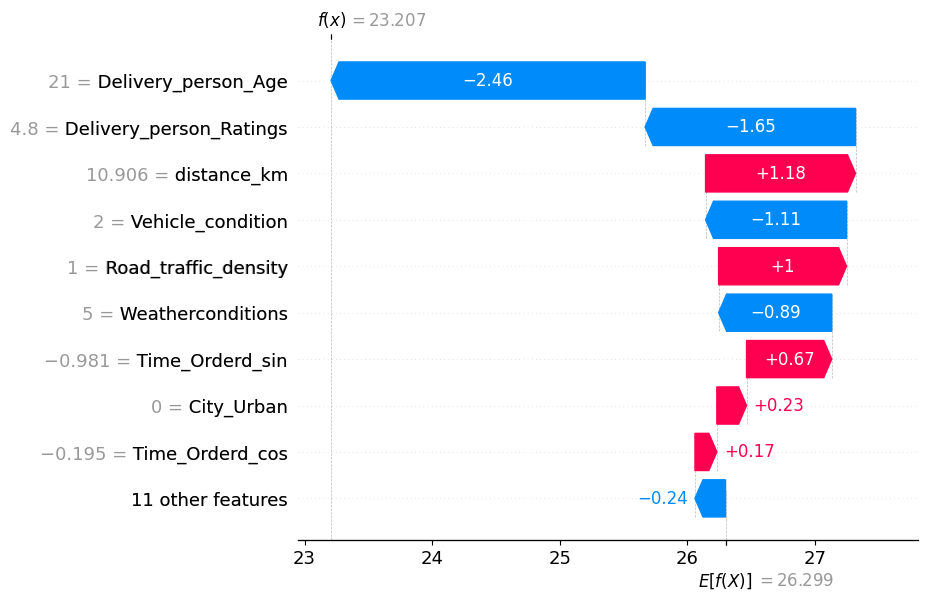

In [15]:
import shap
import matplotlib.pyplot as plt

print("="*60)
print("PHASE 5: SHAP INTERPRETABILITY (THE BLACK BOX REVEALED)")
print("="*60)

# 1. Initialize JS for Kaggle visualization (if needed)
shap.initjs()

# 2. Create the Tree Explainer for our tuned XGBoost model
print("🔍 Calculating SHAP values (This might take a minute)...")
explainer = shap.TreeExplainer(tuned_model)

# Kaggle RAM ko bachane ke liye validation set ka sample lenge
X_val_sample = X_val.sample(n=1000, random_state=42)
shap_values = explainer(X_val_sample)

# 3. Global Interpretability: The Summary Plot
print("\n📊 1. THE SUMMARY PLOT (Macro View)")
print("Showing the overall impact of features across the dataset:")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_sample)
plt.show()

# 4. Local Interpretability: The Waterfall Plot (Micro View)
print("\n🌊 2. THE WATERFALL PLOT (Micro View - Single Delivery)")
print("Dissecting the exact math behind the VERY FIRST delivery in our sample:")
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0])
plt.show()